In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [3]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 세 테이블이 모두 준비됩니다.
# 오늘의 초점은 '병합'이므로, 날짜는 분석 가능한 형태(datetime)로 깔끔하게 둡니다.
# (문자열·날짜 오염 정제는 다음 시간 D+005의 주제입니다.)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) — 고객 1명이 한 행
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int).clip(18, 70),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})

# 2) 상품(products) — 상품 1종이 한 행
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 주문 1건이 한 행. customer_id·product_id로 위 두 표와 연결됩니다.
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity
order_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D")

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.5, 0.5]),
    "order_date": order_dates,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (300, 5) | products: (40, 3) | orders: (2000, 7)


In [4]:
# 세 테이블의 첫인상을 잡아봅니다. 어떤 컬럼이 공통(키)인지 눈으로 찾아보세요.
print("=== orders (주문) — customer_id, product_id 두 개의 키를 가집니다 ===")
display(orders.head())
print("\n=== customers (고객) — customer_id가 키 ===")
display(customers.head(3))
print("\n=== products (상품) — product_id가 키 ===")
display(products.head(3))

=== orders (주문) — customer_id, product_id 두 개의 키를 가집니다 ===


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-01-03
1,O00002,C0224,P022,1,89900.0,app,2025-01-26
2,O00003,C0115,P034,1,49900.0,app,2025-02-26
3,O00004,C0186,P029,1,89900.0,web,2025-01-24
4,O00005,C0056,P004,3,149700.0,web,2025-02-22



=== customers (고객) — customer_id가 키 ===


,customer_id,age,gender,region,membership
0,C0001,39,M,경기,premium
1,C0002,34,F,부산,basic
2,C0003,41,F,서울,premium



=== products (상품) — product_id가 키 ===


,product_id,category,price
0,P001,가전,89900
1,P002,식품,9900
2,P003,도서,9900


In [5]:
# 예제: 월별로 쪼개진 주문 파일을 흉내 내기 — orders를 1월/2월로 나눕니다.
orders_jan = orders[orders["order_date"].dt.month == 1].copy()
orders_feb = orders[orders["order_date"].dt.month == 2].copy()

print("1월 주문:", orders_jan.shape, "| 2월 주문:", orders_feb.shape)

# 세로로 이어 붙이기(axis=0). ignore_index=True로 인덱스를 0부터 다시 매깁니다.
orders_1_2 = pd.concat([orders_jan, orders_feb], axis=0, ignore_index=True)
print("합친 결과:", orders_1_2.shape, "  ← 1월 행 수 + 2월 행 수")
display(orders_1_2.head(3))

1월 주문: (545, 7) | 2월 주문: (435, 7)
합친 결과: (980, 7)   ← 1월 행 수 + 2월 행 수


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0040,P017,1,19900.0,web,2025-01-03
1,O00002,C0224,P022,1,89900.0,app,2025-01-26
2,O00004,C0186,P029,1,89900.0,web,2025-01-24


In [6]:
# 예제: keys로 '어느 달에서 왔는지' 라벨 달기
# 합친 뒤 출처를 구분해야 할 때 유용합니다.
labeled = pd.concat(
    [orders_jan, orders_feb],
    keys=["2025-01", "2025-02"],   # 바깥 인덱스로 출처 라벨이 붙습니다.
    names=["월", None],
)
print("바깥 인덱스(월)로 출처가 구분됩니다:")
display(labeled.head(3))

# 각 달이 몇 건인지 바깥 인덱스로 세어보기
print("\n월별 주문 건수:")
print(labeled.groupby(level="월").size())

바깥 인덱스(월)로 출처가 구분됩니다:


order_id customer_id product_id  quantity   amount channel  \
월                                                                      
2025-01 0   O00001       C0040       P017         1  19900.0     web   
        1   O00002       C0224       P022         1  89900.0     app   
        3   O00004       C0186       P029         1  89900.0     web   

          order_date  
월                     
2025-01 0 2025-01-03  
        1 2025-01-26  
        3 2025-01-24


월별 주문 건수:
월
2025-01    545
2025-02    435
dtype: int64


In [7]:
# 스스로 해보자! (1)
# 1) 3월 주문, 4월 주문을 각각 만들어 보세요.
orders_mar = orders[orders["order_date"].dt.month == 3].copy()
orders_apr = orders[orders["order_date"].dt.month == 4].copy()

orders_3_4 = pd.concat([orders_mar, orders_apr], axis=0, ignore_index=True)
print("합치기 전:", orders_mar.shape, "  ← 3월 행 수 ")
print("합치기 전:", orders_apr.shape, "  ← 4월 행 수 ")
print("합친 결과:", orders_3_4.shape, "  ← 3월 행 수 + 4월 행 수")
display(orders_3_4.head(3))

합치기 전: (521, 7)   ← 3월 행 수 
합치기 전: (499, 7)   ← 4월 행 수 
합친 결과: (1020, 7)   ← 3월 행 수 + 4월 행 수


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00006,C0040,P005,1,129900.0,web,2025-03-11
1,O00008,C0237,P021,2,19800.0,web,2025-03-01
2,O00012,C0147,P019,1,19900.0,web,2025-03-17


In [8]:
# 예제: orders + customers를 customer_id로 병합 (left 조인)
# how="left": orders(왼쪽)는 전부 남기고, 각 주문에 해당 고객 정보를 붙입니다.
orders_cust = pd.merge(orders, customers, on="customer_id", how="left")

print("병합 전 orders:", orders.shape, "→ 병합 후:", orders_cust.shape)
print("컬럼이 늘었습니다:", list(orders_cust.columns))
display(orders_cust.head(3))

병합 전 orders: (2000, 7) → 병합 후: (2000, 11)
컬럼이 늘었습니다: ['order_id', 'customer_id', 'product_id', 'quantity', 'amount', 'channel', 'order_date', 'age', 'gender', 'region', 'membership']


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership
0,O00001,C0040,P017,1,19900.0,web,2025-01-03,37,M,경기,premium
1,O00002,C0224,P022,1,89900.0,app,2025-01-26,20,M,대구,premium
2,O00003,C0115,P034,1,49900.0,app,2025-02-26,33,M,경기,basic


In [9]:
# 예제: 조인 유형 4종 비교 — 일부러 '짝이 안 맞는' 작은 표로 차이를 봅니다.
left = pd.DataFrame({"id": ["A", "B", "C"], "left_val": [1, 2, 3]})
right = pd.DataFrame({"id": ["B", "C", "D"], "right_val": [20, 30, 40]})

print("왼쪽 표 (id: A,B,C)");  display(left)
print("오른쪽 표 (id: B,C,D)"); display(right)

for how in ["inner", "left", "right", "outer"]:
    merged = pd.merge(left, right, on="id", how=how)
    print(f"\n--- how='{how}' → {len(merged)}행 ---")
    display(merged)

왼쪽 표 (id: A,B,C)


,id,left_val
0,A,1
1,B,2
2,C,3


오른쪽 표 (id: B,C,D)


,id,right_val
0,B,20
1,C,30
2,D,40



--- how='inner' → 2행 ---


...

,id,left_val,right_val
0,A,1,NaN
1,B,2,20.0
2,C,3,30.0



--- how='right' → 3행 ---


,id,left_val,right_val
0,B,2.0,20
1,C,3.0,30
2,D,NaN,40



--- how='outer' → 4행 ---


,id,left_val,right_val
0,A,1.0,NaN
1,B,2.0,20.0
2,C,3.0,30.0
3,D,NaN,40.0


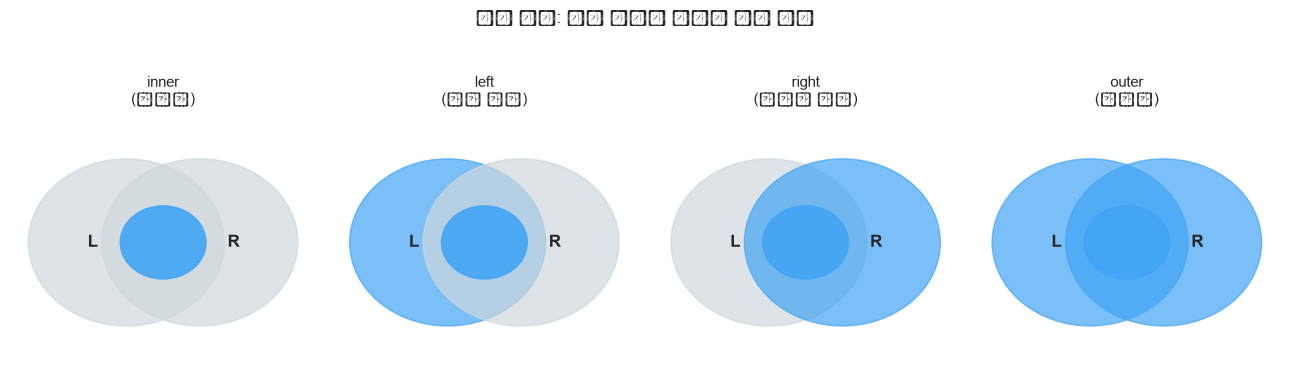

In [10]:
# ─────────────────────────────────────────────
# [도식] 조인 유형 4종을 벤다이어그램으로
# ─────────────────────────────────────────────
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
titles = ["inner\n(교집합)", "left\n(왼쪽 전부)", "right\n(오른쪽 전부)", "outer\n(합집합)"]
# (왼쪽칠, 교집합칠, 오른쪽칠)
fills = [(False, True, False), (True, True, False), (False, True, True), (True, True, True)]

for ax, title, (lf, mf, rf) in zip(axes, titles, fills):
    base = "#cfd8dc"
    hi = "#42a5f5"
    # 왼쪽 원
    ax.add_patch(Circle((0.38, 0.5), 0.32, color=hi if lf else base, alpha=0.7))
    # 오른쪽 원
    ax.add_patch(Circle((0.62, 0.5), 0.32, color=hi if rf else base, alpha=0.7))
    # 교집합은 색을 한 번 더 덧칠해 강조(겹침)
    if mf:
        ax.add_patch(Circle((0.5, 0.5), 0.14, color=hi, alpha=0.9))
    ax.text(0.27, 0.5, "L", ha="center", va="center", fontsize=12, weight="bold")
    ax.text(0.73, 0.5, "R", ha="center", va="center", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

plt.suptitle("조인 유형: 파란 영역이 결과에 남는 부분", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# 스스로 해보자! (2)
# orders_cust 에 products를 product_id로 left 병합해 보세요.
# full = pd.merge(...)
orders_full = pd.merge(orders_cust, products, on="product_id", how="left")
# 병합 후 shape와 컬럼, head(3)를 확인해 보세요.
print("병합 후:", orders_full.head(3))

병합 후:   order_id customer_id product_id  quantity   amount channel order_date  age  \
0   O00001       C0040       P017         1  19900.0     web 2025-01-03   37   
1   O00002       C0224       P022         1  89900.0     app 2025-01-26   20   
2   O00003       C0115       P034         1  49900.0     app 2025-02-26   33   

  gender region membership category  price  
0      M     경기    premium       패션  19900  
1      M     대구    premium       식품  89900  
2      M     경기      basic       식품  49900  


In [12]:
# 검증 1) customers의 키(customer_id)에 중복이 있는가? (유일해야 정상)
dup_cust = customers["customer_id"].duplicated().sum()
print(f"customers의 customer_id 중복 개수: {dup_cust}건  →", "정상(유일)" if dup_cust == 0 else "⚠ 중복 있음!")

# 검증 2) orders의 customer_id 중 customers에 없는 키(짝 없는 키)가 있는가?
orphan = ~orders["customer_id"].isin(customers["customer_id"])
print(f"customers에 짝이 없는 주문 키: {orphan.sum()}건  →", "정상(모두 매칭)" if orphan.sum() == 0 else "⚠ 미매칭 있음!")

# 검증 3) products의 키도 같은 방식으로
print(f"products의 product_id 중복 개수: {products['product_id'].duplicated().sum()}건")

customers의 customer_id 중복 개수: 0건  → 정상(유일)
customers에 짝이 없는 주문 키: 0건  → 정상(모두 매칭)
products의 product_id 중복 개수: 0건


In [13]:
# 예제: '행 폭증' 사고를 일부러 재현하기
# products에 같은 product_id가 두 번 들어간 '오염된' 룩업 표를 만듭니다.
products_dirty = pd.concat([products, products.iloc[[0, 1]]], ignore_index=True)
print("정상 products:", products.shape, "→ 오염 products_dirty:", products_dirty.shape, "(P001, P002 중복)")

# 이 오염된 표로 병합하면?
boom = pd.merge(orders, products_dirty, on="product_id", how="left")
print(f"\n병합 전 orders 행 수: {len(orders)}")
print(f"병합 후 행 수:        {len(boom)}   ← 행이 늘었습니다! (중복 키 때문에 폭증)")
print(f"늘어난 행: {len(boom) - len(orders)}건")

정상 products: (40, 3) → 오염 products_dirty: (42, 3) (P001, P002 중복)

병합 전 orders 행 수: 2000
병합 후 행 수:        2092   ← 행이 늘었습니다! (중복 키 때문에 폭증)
늘어난 행: 92건


In [14]:
# 예제: validate로 '관계 가정'을 강제하기
# "m:1" = 왼쪽은 여러 행(many), 오른쪽 키는 유일(one)해야 한다는 가정.
# 가정이 깨지면 merge가 '에러를 내며' 알려줍니다 — 조용한 사고보다 훨씬 낫습니다.

# 1) 깨끗한 products로는 통과합니다.
ok = pd.merge(orders, products, on="product_id", how="left", validate="m:1")
print("깨끗한 products → validate='m:1' 통과:", ok.shape)

# 2) 오염된 products_dirty로는 일부러 에러를 내봅니다 (오류 읽는 법 익히기).
try:
    pd.merge(orders, products_dirty, on="product_id", how="left", validate="m:1")
except Exception as e:
    print("\n오염된 products_dirty → 에러 발생 (의도된 것입니다):")
    print(f"  {type(e).__name__}: {e}")

깨끗한 products → validate='m:1' 통과: (2000, 9)

오염된 products_dirty → 에러 발생 (의도된 것입니다):
  MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
 product_id
      P001
      P002 ...


In [15]:
# 예제: indicator로 '어느 쪽에서 왔는지' 표시하기
# 짝이 없는 키를 일부러 만든 뒤, 어떤 행이 매칭 안 됐는지 _merge 열로 확인합니다.
customers_subset = customers.iloc[:250]   # 일부 고객을 일부러 빼서 '짝 없는 키'를 만듭니다.

checked = pd.merge(orders, customers_subset, on="customer_id", how="left", indicator=True)
print("_merge 열의 값 분포:")
print(checked["_merge"].value_counts())

n_unmatched = (checked["_merge"] == "left_only").sum()
print(f"\n고객 정보가 비어 있는(짝 없는) 주문: {n_unmatched}건")
print("→ 이 행들은 age·region이 NaN입니다. 모르고 평균 내면 왜곡됩니다.")

_merge 열의 값 분포:
_merge
both          1679
left_only      321
right_only       0
Name: count, dtype: int64

고객 정보가 비어 있는(짝 없는) 주문: 321건
→ 이 행들은 age·region이 NaN입니다. 모르고 평균 내면 왜곡됩니다.


In [16]:
# 스스로 해보자! (3)
# orders + customers를 customer_id로 left 병합하되
# validate="m:1" 과 indicator=True 를 함께 걸어 보세요.
result = pd.merge(orders, customers, on="customer_id", how="left", validate="m:1", indicator=True)
print(result.head(3))

  order_id customer_id product_id  quantity   amount channel order_date  age  \
0   O00001       C0040       P017         1  19900.0     web 2025-01-03   37   
1   O00002       C0224       P022         1  89900.0     app 2025-01-26   20   
2   O00003       C0115       P034         1  49900.0     app 2025-02-26   33   

  gender region membership _merge  
0      M     경기    premium   both  
1      M     대구    premium   both  
2      M     경기      basic   both  


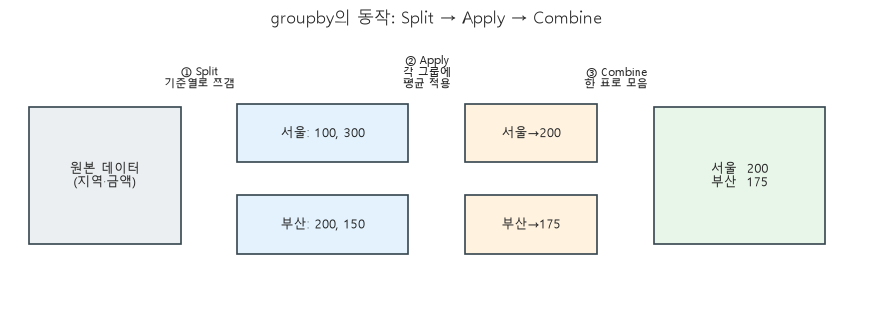

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# OS별 한글 폰트 설정
system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
# ─────────────────────────────────────────────
# [도식] split-apply-combine 흐름
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axis("off")

def box(x, y, w, h, text, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#37474f", lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9)

# 원본
box(0.02, 0.30, 0.16, 0.42, "원본 데이터\n(지역·금액)", "#eceff1")
ax.annotate("", xy=(0.22, 0.5), xytext=(0.18, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.20, 0.78, "① Split\n기준열로 쪼갬", ha="center", fontsize=8)

# 그룹들
box(0.24, 0.55, 0.18, 0.18, "서울: 100, 300", "#e3f2fd")
box(0.24, 0.27, 0.18, 0.18, "부산: 200, 150", "#e3f2fd")
ax.annotate("", xy=(0.46, 0.5), xytext=(0.42, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.44, 0.78, "② Apply\n각 그룹에\n평균 적용", ha="center", fontsize=8)

# 적용 결과
box(0.48, 0.55, 0.14, 0.18, "서울→200", "#fff3e0")
box(0.48, 0.27, 0.14, 0.18, "부산→175", "#fff3e0")
ax.annotate("", xy=(0.66, 0.5), xytext=(0.62, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.64, 0.78, "③ Combine\n한 표로 모음", ha="center", fontsize=8)

# 최종
box(0.68, 0.30, 0.18, 0.42, "서울  200\n부산  175", "#e8f5e9")

ax.set_xlim(0, 0.9); ax.set_ylim(0.1, 0.95)
plt.title("groupby의 동작: Split → Apply → Combine", fontsize=12)
plt.show()

In [18]:
# 분석용 통합 표를 안전하게 다시 만듭니다 (validate로 관계 확인).
full = (
    orders
    .merge(customers, on="customer_id", how="left", validate="m:1")
    .merge(products, on="product_id", how="left", validate="m:1")
)
print("통합 표 full:", full.shape)

# 예제 1) 지역별 평균 주문 금액 — 한 열, 한 함수
region_mean = full.groupby("region")["amount"].mean().round(0)
print("\n[지역별 평균 주문 금액]")
print(region_mean)

통합 표 full: (2000, 13)

[지역별 평균 주문 금액]
region
경기    78616.0
대구    76316.0
부산    80983.0
서울    80417.0
인천    83677.0
Name: amount, dtype: float64


In [19]:
# 예제 2) 여러 통계를 한 번에 + 컬럼 이름 지정 (named aggregation)
# 카테고리별로 매출 합계·평균 금액·주문 건수를 한 표로.
category_summary = (
    full.groupby("category")
    .agg(
        매출합계=("amount", "sum"),
        평균금액=("amount", "mean"),
        주문건수=("order_id", "count"),
        평균수량=("quantity", "mean"),
    )
    .round(1)
    .sort_values("매출합계", ascending=False)
)
print("[카테고리별 요약 — 매출 내림차순]")
display(category_summary)

[카테고리별 요약 — 매출 내림차순]


,매출합계,평균금액,주문건수,평균수량
category,,,,
식품,55973400.0,109537.0,511,1.7
뷰티,34568800.0,80020.4,432,1.6
패션,28351600.0,68814.6,412,1.7
도서,21984300.0,54282.2,405,1.6
가전,18920900.0,78837.1,240,1.6


In [20]:
# 예제 3) 두 기준으로 그룹 나누기 — 지역 × 회원등급 교차 평균 금액
region_member = (
    full.groupby(["region", "membership"])["amount"]
    .mean().round(0)
    .unstack()   # membership을 열로 펼쳐 보기 좋게 (Part 6에서 자세히)
)
print("[지역 × 회원등급 평균 주문 금액]")
display(region_member)

[지역 × 회원등급 평균 주문 금액]


membership,basic,premium,vip
region,,,
경기,80622.0,76234.0,75059.0
대구,74169.0,85365.0,60374.0
부산,80731.0,84822.0,70329.0
서울,85657.0,65652.0,78330.0
인천,76956.0,89606.0,88488.0


In [21]:
# 스스로 해보자! (4)
# full을 membership으로 그룹지어, named aggregation으로 세 통계를 내보세요.
membership_summary = (
    full.groupby("membership")
    .agg(
        매출합계=("amount", "sum"),
        평균금액=("amount", "mean"),
        주문건수=("order_id", "count")
    )
    .round(1)
    .sort_values("매출합계", ascending=False)
)
display(membership_summary)

,매출합계,평균금액,주문건수
membership,,,
basic,96340900.0,79752.4,1208
premium,47063000.0,81003.4,581
vip,16395100.0,77701.9,211


In [22]:
# 예제 1) 각 주문에 '그 카테고리의 평균 금액'을 컬럼으로 붙이기
full["category_avg"] = full.groupby("category")["amount"].transform("mean").round(0)

# '그 주문이 카테고리 평균보다 큰가' (편차) 컬럼도 추가
full["diff_from_avg"] = (full["amount"] - full["category_avg"]).round(0)

print("transform은 행을 줄이지 않습니다. full 행 수:", len(full), "(여전히 2000)")
display(full[["order_id", "category", "amount", "category_avg", "diff_from_avg"]].head(6))

transform은 행을 줄이지 않습니다. full 행 수: 2000 (여전히 2000)


,order_id,category,amount,category_avg,diff_from_avg
0,O00001,패션,19900.0,68815.0,-48915.0
1,O00002,식품,89900.0,109537.0,-19637.0
2,O00003,식품,49900.0,109537.0,-59637.0
3,O00004,뷰티,89900.0,80020.0,9880.0
4,O00005,뷰티,149700.0,80020.0,69680.0
5,O00006,패션,129900.0,68815.0,61085.0


In [23]:
# 예제 2) 그룹 내 '비중(점유율)' 계산 — 각 주문이 그 카테고리 매출에서 차지하는 비율
cat_total = full.groupby("category")["amount"].transform("sum")
full["share_in_category"] = (full["amount"] / cat_total * 100).round(3)

print("각 주문이 '그 카테고리 전체 매출'에서 차지하는 비중(%):")
display(full[["order_id", "category", "amount", "share_in_category"]].head(6))

# 검산: 한 카테고리의 share를 모두 더하면 100%가 되어야 합니다.
check = full[full["category"] == "패션"]["share_in_category"].sum()
print(f"\n검산 — '패션' 카테고리 비중 합계: {check:.1f}%  (100%면 정상)")

각 주문이 '그 카테고리 전체 매출'에서 차지하는 비중(%):


,order_id,category,amount,share_in_category
0,O00001,패션,19900.0,0.070
1,O00002,식품,89900.0,0.161
2,O00003,식품,49900.0,0.089
3,O00004,뷰티,89900.0,0.260
4,O00005,뷰티,149700.0,0.433
5,O00006,패션,129900.0,0.458



검산 — '패션' 카테고리 비중 합계: 100.0%  (100%면 정상)


In [24]:
# 스스로 해보자! (5)
# customer_id로 그룹지어 amount의 평균을 transform으로 각 행에 붙여 보세요.
full["customer_avg"] = full.groupby("customer_id")["amount"].transform("mean").round(0)

# 자기 고객 평균보다 큰 주문(amount > customer_avg)이 몇 건인지 세어 보세요.
count = (full["amount"] > full["customer_avg"]).sum()
print(f"자기 고객 평균보다 큰 주문 건수: {count}건")

자기 고객 평균보다 큰 주문 건수: 755건


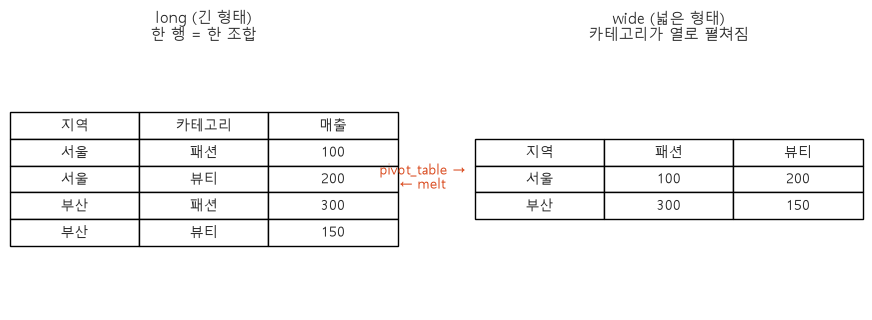

In [25]:
# ─────────────────────────────────────────────
# [도식] long ↔ wide 변환
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

long_demo = [["서울", "패션", 100], ["서울", "뷰티", 200],
             ["부산", "패션", 300], ["부산", "뷰티", 150]]
axes[0].axis("off")
axes[0].set_title("long (긴 형태)\n한 행 = 한 조합", fontsize=11)
tbl0 = axes[0].table(cellText=long_demo, colLabels=["지역", "카테고리", "매출"],
                     loc="center", cellLoc="center")
tbl0.scale(1, 1.6)

wide_demo = [["서울", 100, 200], ["부산", 300, 150]]
axes[1].axis("off")
axes[1].set_title("wide (넓은 형태)\n카테고리가 열로 펼쳐짐", fontsize=11)
tbl1 = axes[1].table(cellText=wide_demo, colLabels=["지역", "패션", "뷰티"],
                     loc="center", cellLoc="center")
tbl1.scale(1, 1.6)

fig.text(0.5, 0.5, "pivot_table →\n← melt", ha="center", va="center", fontsize=10, color="#d84315")
plt.show()

In [26]:
# 예제 1) pivot_table — 지역(행) × 카테고리(열) 매출 합계 교차표
pivot = pd.pivot_table(
    full,
    index="region",        # 행이 될 기준
    columns="category",    # 열이 될 기준
    values="amount",       # 채울 값
    aggfunc="sum",         # 집계 방법 (합계)
    margins=True,          # 행/열 합계(All) 추가
    margins_name="합계",
).round(0)

print("[지역 × 카테고리 매출 교차표]")
display(pivot)

[지역 × 카테고리 매출 교차표]


category,가전,도서,뷰티,식품,패션,합계
region,,,,,,
경기,2912100.0,4206800.0,6676300.0,11302600.0,6505900.0,31603700.0
대구,4142700.0,4524100.0,6944400.0,10673500.0,5386500.0,31671200.0
부산,5080100.0,5056400.0,7225600.0,10324400.0,6164400.0,33850900.0
서울,2693200.0,4337200.0,7234700.0,13968500.0,4817900.0,33051500.0
인천,4092800.0,3859800.0,6487800.0,9704400.0,5476900.0,29621700.0
합계,18920900.0,21984300.0,34568800.0,55973400.0,28351600.0,159799000.0


In [27]:
# 예제 2) 시간 축 피벗 — 월별 × 카테고리 매출 (실무에서 가장 흔한 형태)
full["month"] = full["order_date"].dt.to_period("M").astype(str)   # 'YYYY-MM'

month_cat = pd.pivot_table(
    full, index="month", columns="category", values="amount",
    aggfunc="sum", fill_value=0,   # 빈 칸은 0으로
).round(0)
print("[월별 × 카테고리 매출]")
display(month_cat)

[월별 × 카테고리 매출]


category,가전,도서,뷰티,식품,패션
month,,,,,
2025-01,4789500.0,6519100.0,9231500.0,14877000.0,6662400.0
2025-02,4201800.0,6364500.0,7723400.0,9683200.0,5754700.0
2025-03,4919900.0,5053900.0,8431900.0,16556800.0,8212000.0
2025-04,5009700.0,4046800.0,9182000.0,14856400.0,7722500.0


In [28]:
# 예제 3) melt — wide를 다시 long으로 (그래프나 저장에 유리한 형태)
month_cat_reset = month_cat.reset_index()
long_form = month_cat_reset.melt(
    id_vars="month",          # 고정할 열
    var_name="category",      # 펼쳐졌던 열 이름이 들어갈 새 컬럼
    value_name="amount",      # 값이 들어갈 새 컬럼
)
print("wide → long 복원 (앞 6행):")
display(long_form.head(6))

# stack/unstack도 같은 일을 합니다: unstack은 wide로 펼치고, stack은 long으로 접습니다.
print("\nstack()으로 다시 접기 (long 형태, 앞부분):")
print(month_cat.stack().head(4))

wide → long 복원 (앞 6행):


,month,category,amount
0,2025-01,가전,4789500.0
1,2025-02,가전,4201800.0
2,2025-03,가전,4919900.0
3,2025-04,가전,5009700.0
4,2025-01,도서,6519100.0
5,2025-02,도서,6364500.0



stack()으로 다시 접기 (long 형태, 앞부분):
month    category
2025-01  가전           4789500.0
         도서           6519100.0
         뷰티           9231500.0
         식품          14877000.0
dtype: float64


In [31]:
# 스스로 해보자! (6)
# index=membership, columns=region, values=amount, aggfunc='mean'
member_region = pd.pivot_table(full, index="membership", columns="region", values="amount", aggfunc="mean").round(0)
print("[회원등급 × 지역 평균 주문 금액]")
display(member_region)

[회원등급 × 지역 평균 주문 금액]


region,경기,대구,부산,서울,인천
membership,,,,,
basic,80622.0,74169.0,80731.0,85657.0,76956.0
premium,76234.0,85365.0,84822.0,65652.0,89606.0
vip,75059.0,60374.0,70329.0,78330.0,88488.0


In [39]:
# ─────────────────────────────────────────────
# 종합 실습용 데이터 — 새 스냅샷 (이 셀부터 단독 실행 가능)
# ─────────────────────────────────────────────
np.random.seed(7)

n_cust = 200
cust = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_cust + 1)],
    "region": np.random.choice(["서울", "경기", "부산", "인천"], n_cust),
    "membership": np.random.choice(["basic", "premium", "vip"], n_cust, p=[0.6, 0.3, 0.1]),
})

cats = ["패션", "뷰티", "식품", "가전"]
n_prod = 30
prod = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_prod + 1)],
    "category": np.random.choice(cats, n_prod),
    "price": np.random.choice([12000, 25000, 40000, 75000], n_prod),
})

n_ord = 1500
oc = np.random.choice(cust["customer_id"], n_ord)
op = np.random.choice(prod["product_id"], n_ord)
qty = np.random.choice([1, 1, 2, 3], n_ord)
amt = prod.set_index("product_id")["price"].loc[op].values * qty
odate = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 150, n_ord), unit="D")
ordr = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_ord + 1)],
    "customer_id": oc, "product_id": op,
    "quantity": qty, "amount": amt.astype(float), "order_date": odate,
})
print("스냅샷 준비 완료 — orders:", ordr.shape, "| customers:", cust.shape, "| products:", prod.shape)

스냅샷 준비 완료 — orders: (1500, 6) | customers: (200, 3) | products: (30, 3)


In [40]:
# 시나리오 1 — 검증 → 병합
# (1) 검증: 룩업 표의 키가 유일한가, 주문의 키가 모두 매칭되는가
print("[병합 전 검증]")
print("  customers 키 중복:", cust["customer_id"].duplicated().sum(), "건")
print("  products  키 중복:", prod["product_id"].duplicated().sum(), "건")
print("  매칭 안 되는 customer_id:", (~ordr["customer_id"].isin(cust["customer_id"])).sum(), "건")
print("  매칭 안 되는 product_id :", (~ordr["product_id"].isin(prod["product_id"])).sum(), "건")

# (2) 병합: validate로 관계 가정(m:1)을 강제. indicator로 매칭 확인.
df = (
    ordr
    .merge(cust, on="customer_id", how="left", validate="m:1")
    .merge(prod, on="product_id", how="left", validate="m:1")
)
print("\n[병합 결과] 행 수:", len(df), "(원본 주문 수와 같으면 폭증 없음)")
display(df.head(3))
print(df.columns)

[병합 전 검증]
  customers 키 중복: 0 건
  products  키 중복: 0 건
  매칭 안 되는 customer_id: 0 건
  매칭 안 되는 product_id : 0 건

[병합 결과] 행 수: 1500 (원본 주문 수와 같으면 폭증 없음)


,order_id,customer_id,product_id,quantity,amount,order_date,region,membership,category,price
0,O00001,C0032,P005,3,120000.0,2025-04-12,서울,premium,패션,40000
1,O00002,C0049,P020,1,25000.0,2025-03-09,서울,basic,식품,25000
2,O00003,C0041,P016,3,36000.0,2025-01-27,인천,basic,패션,12000


Index(['order_id', 'customer_id', 'product_id', 'quantity', 'amount',
       'order_date', 'region', 'membership', 'category', 'price'],
      dtype='str')


검증 결과 
  customers 키 중복: 0 건
  products  키 중복: 0 건
  매칭 안 되는 customer_id: 0 건
  매칭 안 되는 product_id : 0 건
이므로 m:1 병합이 안전하다.

In [41]:
# 시나리오 2 — 월별 KPI
df["month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_kpi = (
    df.groupby("month")
    .agg(
        총매출=("amount", "sum"),
        주문건수=("order_id", "count"),
        객단가=("amount", "mean"),
        구매고객수=("customer_id", "nunique"),   # nunique: 고유 고객 수
    )
    .round(0)
)
# 전월 대비 매출 증감률(%)도 추가 — 경영 보고서의 단골 지표
monthly_kpi["매출증감률(%)"] = (monthly_kpi["총매출"].pct_change() * 100).round(1)

print("[월별 KPI 요약표]")
display(monthly_kpi)

[월별 KPI 요약표]


,총매출,주문건수,객단가,구매고객수,매출증감률(%)
month,,,,,
2025-01,19902000.0,330,60309.0,163,NaN
2025-02,17043000.0,289,58972.0,160,-14.4
2025-03,20035000.0,326,61457.0,156,17.6
2025-04,17602000.0,287,61331.0,156,-12.1
2025-05,16374000.0,268,61097.0,146,-7.0


In [42]:
# 시나리오 3-1 — 월 × 카테고리 매출 교차표 (pivot_table)
month_category = pd.pivot_table(
    df, index="month", columns="category", values="amount",
    aggfunc="sum", fill_value=0, margins=True, margins_name="합계",
).round(0)
print("[월 × 카테고리 매출 교차표]")
display(month_category)

# 시나리오 3-2 — 각 주문이 '그 달 전체 매출'에서 차지하는 비중 (transform)
df["month_total"] = df.groupby("month")["amount"].transform("sum")
df["share_in_month(%)"] = (df["amount"] / df["month_total"] * 100).round(3)
print("\n[주문별 월 매출 점유율 — 앞 5행]")
display(df[["order_id", "month", "amount", "share_in_month(%)"]].sort_values(
    "share_in_month(%)", ascending=False
))

[월 × 카테고리 매출 교차표]


category,가전,뷰티,식품,패션,합계
month,,,,,
2025-01,5001000.0,2183000.0,4436000.0,8282000.0,19902000.0
2025-02,3752000.0,2433000.0,4778000.0,6080000.0,17043000.0
2025-03,4572000.0,1482000.0,4531000.0,9450000.0,20035000.0
2025-04,3998000.0,1954000.0,4858000.0,6792000.0,17602000.0
2025-05,2925000.0,1934000.0,3801000.0,7714000.0,16374000.0
합계,20248000.0,9986000.0,22404000.0,38318000.0,90956000.0



[주문별 월 매출 점유율 — 앞 5행]


,order_id,month,amount,share_in_month(%)
1279,O01280,2025-05,225000.0,1.374
1264,O01265,2025-05,225000.0,1.374
452,O00453,2025-05,225000.0,1.374
472,O00473,2025-05,225000.0,1.374
448,O00449,2025-05,225000.0,1.374
...,...,...,...,...
933,O00934,2025-03,12000.0,0.060
934,O00935,2025-01,12000.0,0.060
302,O00303,2025-01,12000.0,0.060
1440,O01441,2025-03,12000.0,0.060


In [43]:
# 핵심 숫자 자동 추출 (보고서 문장에 채워 넣기 위함)
best_month = monthly_kpi["총매출"].idxmax()
best_month_sales = monthly_kpi["총매출"].max()
top_category = df.groupby("category")["amount"].sum().idxmax()
top_region = df.groupby("region")["amount"].sum().idxmax()
overall_aov = df["amount"].mean()

print("자동 추출된 핵심 숫자")
print(f"  최대 매출 월   : {best_month} ({best_month_sales:,.0f}원)")
print(f"  최대 매출 카테고리: {top_category}")
print(f"  최대 매출 지역 : {top_region}")
print(f"  전체 객단가    : {overall_aov:,.0f}원")

자동 추출된 핵심 숫자
  최대 매출 월   : 2025-03 (20,035,000원)
  최대 매출 카테고리: 패션
  최대 매출 지역 : 인천
  전체 객단가    : 60,637원


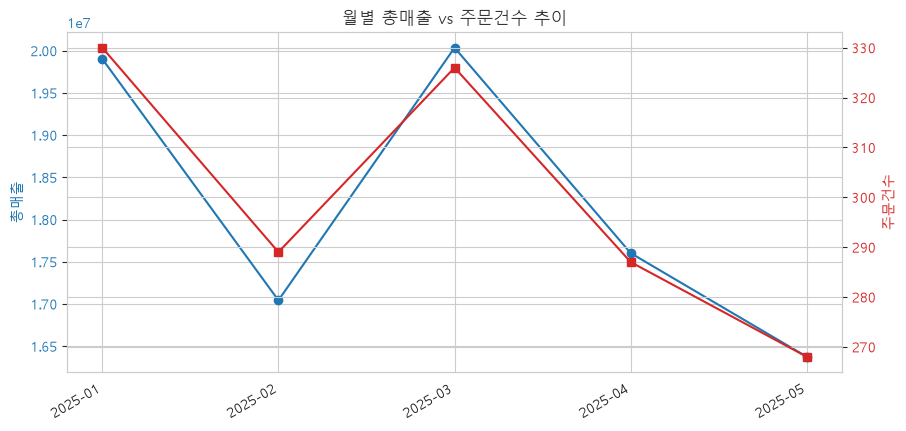

In [48]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(monthly_kpi.index, monthly_kpi["총매출"], color="tab:blue", marker="o", label="총매출")
ax1.set_ylabel("총매출", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(monthly_kpi.index, monthly_kpi["주문건수"], color="tab:red", marker="s", label="주문건수")
ax2.set_ylabel("주문건수", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("월별 총매출 vs 주문건수 추이")
fig.autofmt_xdate()
plt.show()

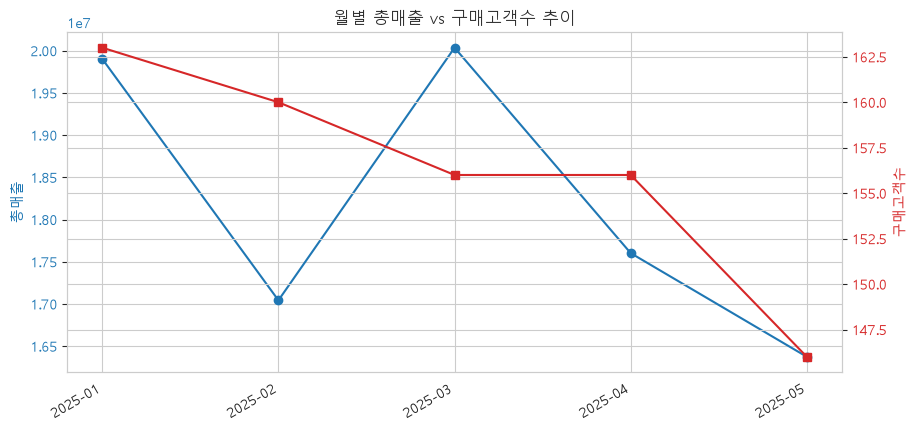

In [49]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(monthly_kpi.index, monthly_kpi["총매출"], color="tab:blue", marker="o", label="총매출")
ax1.set_ylabel("총매출", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(monthly_kpi.index, monthly_kpi["구매고객수"], color="tab:red", marker="s", label="구매고객수")
ax2.set_ylabel("구매고객수", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("월별 총매출 vs 구매고객수 추이")
fig.autofmt_xdate()
plt.show()

[카테고리별 주문건수]
category
패션    512
가전    398
식품    398
뷰티    192
Name: order_id, dtype: int64

[지역별 주문건수]
region
인천    464
서울    397
경기    320
부산    319
Name: order_id, dtype: int64


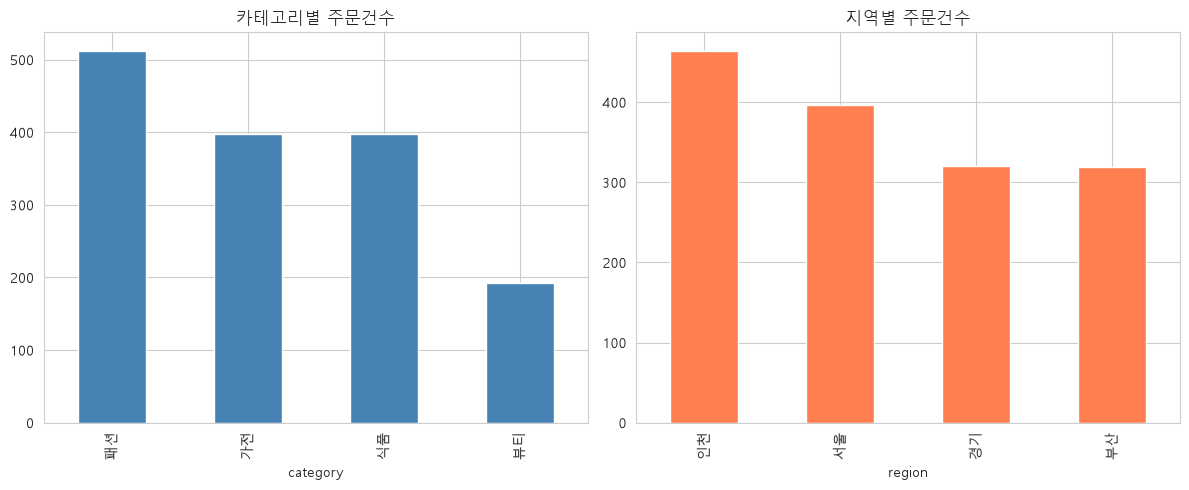

In [54]:
# 카테고리별 / 지역별 주문건수
cat_orders = df.groupby("category")["order_id"].count().sort_values(ascending=False)
region_orders = df.groupby("region")["order_id"].count().sort_values(ascending=False)

print("[카테고리별 주문건수]")
print(cat_orders)
print("\n[지역별 주문건수]")
print(region_orders)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cat_orders.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("카테고리별 주문건수")

region_orders.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("지역별 주문건수")

plt.tight_layout()
plt.show()

[월 × 카테고리 주문건수]


category,가전,뷰티,식품,패션
month,,,,
2025-01,92,48,86,104
2025-02,72,43,79,95
2025-03,99,34,80,113
2025-04,76,38,80,93
2025-05,59,29,73,107



[월 × 지역 주문건수]


region,경기,부산,서울,인천
month,,,,
2025-01,76,62,88,104
2025-02,65,59,75,90
2025-03,75,70,84,97
2025-04,46,71,74,96
2025-05,58,57,76,77


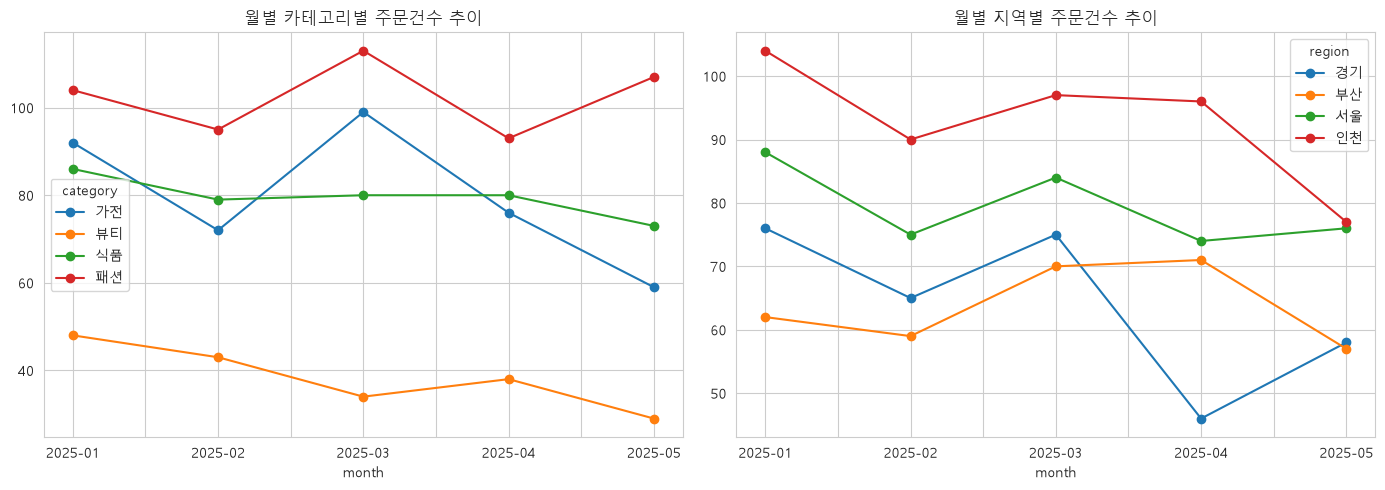

In [53]:
month_cat_cnt = pd.pivot_table(
    df, index="month", columns="category", values="order_id",
    aggfunc="count", fill_value=0
)
print("[월 × 카테고리 주문건수]")
display(month_cat_cnt)

month_region_cnt = pd.pivot_table(
    df, index="month", columns="region", values="order_id",
    aggfunc="count", fill_value=0
)
print("\n[월 × 지역 주문건수]")
display(month_region_cnt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_cat_cnt.plot(ax=axes[0], marker="o")
axes[0].set_title("월별 카테고리별 주문건수 추이")

month_region_cnt.plot(ax=axes[1], marker="o")
axes[1].set_title("월별 지역별 주문건수 추이")

plt.tight_layout()
plt.show()

In [56]:
# 월 × 카테고리 매출 (합계 제외)
cat_amt = month_category.drop(columns="합계", errors="ignore")

# 3월 대비 이후 달 증감액
base = cat_amt.loc["2025-03"]
cat_diff_from_mar = cat_amt.loc["2025-03":].subtract(base, axis=1)
print("[3월 대비 카테고리별 매출 증감액]")
display(cat_diff_from_mar.round(0))

# 전체 낙폭 대비 카테고리별 기여도(%) — 마지막 달 기준
last_month = cat_amt.index[-1]
total_drop = cat_diff_from_mar.loc[last_month].sum()
contribution = (cat_diff_from_mar.loc[last_month] / total_drop * 100).round(1)
print(f"\n[{last_month} 기준, 3월 대비 전체 매출 변화: {total_drop:,.0f}]")
print("[카테고리별 낙폭 기여도(%)]")
display(contribution.sort_values(ascending=False))
cnt_diff_from_mar = month_cat_cnt.loc["2025-03":].subtract(month_cat_cnt.loc["2025-03"], axis=1)
print("[3월 대비 카테고리별 주문건수 증감]")
display(cnt_diff_from_mar)

[3월 대비 카테고리별 매출 증감액]


category,가전,뷰티,식품,패션
month,,,,
2025-03,0.0,0.0,0.0,0.0
2025-04,-574000.0,472000.0,327000.0,-2658000.0
2025-05,-1647000.0,452000.0,-730000.0,-1736000.0
합계,15676000.0,8504000.0,17873000.0,28868000.0



[합계 기준, 3월 대비 전체 매출 변화: 70,921,000]
[카테고리별 낙폭 기여도(%)]


category
패션    40.7
식품    25.2
가전    22.1
뷰티    12.0
Name: 합계, dtype: float64

[3월 대비 카테고리별 주문건수 증감]


category,가전,뷰티,식품,패션
month,,,,
2025-03,0,0,0,0
2025-04,-23,4,0,-20
2025-05,-40,-5,-7,-6


In [57]:
# 월 × 지역 매출 피벗
month_region = pd.pivot_table(
    df, index="month", columns="region", values="amount",
    aggfunc="sum", fill_value=0
)

# 3월 대비 이후 달 매출 증감액
base_r = month_region.loc["2025-03"]
region_diff_from_mar = month_region.loc["2025-03":].subtract(base_r, axis=1)
print("[3월 대비 지역별 매출 증감액]")
display(region_diff_from_mar.round(0))

# 전체 낙폭 대비 지역별 기여도(%) — 마지막 달 기준
last_month = month_region.index[-1]
total_drop_r = region_diff_from_mar.loc[last_month].sum()
contribution_r = (region_diff_from_mar.loc[last_month] / total_drop_r * 100).round(1)
print(f"\n[{last_month} 기준, 3월 대비 전체 매출 변화: {total_drop_r:,.0f}]")
print("[지역별 낙폭 기여도(%)]")
display(contribution_r.sort_values(ascending=False))
region_cnt_diff_from_mar = month_region_cnt.loc["2025-03":].subtract(month_region_cnt.loc["2025-03"], axis=1)
print("[3월 대비 지역별 주문건수 증감]")
display(region_cnt_diff_from_mar)

[3월 대비 지역별 매출 증감액]


region,경기,부산,서울,인천
month,,,,
2025-03,0.0,0.0,0.0,0.0
2025-04,-1697000.0,-203000.0,-1293000.0,760000.0
2025-05,-607000.0,-600000.0,-1229000.0,-1225000.0



[2025-05 기준, 3월 대비 전체 매출 변화: -3,661,000]
[지역별 낙폭 기여도(%)]


region
서울    33.6
인천    33.5
경기    16.6
부산    16.4
Name: 2025-05, dtype: float64

[3월 대비 지역별 주문건수 증감]


region,경기,부산,서울,인천
month,,,,
2025-03,0,0,0,0
2025-04,-29,1,-10,-1
2025-05,-17,-13,-8,-20


# 월 매출 보고서

# 1. 데이터 개요
- 행/열: orders: (1500, 6) | customers: (200, 3) | products: (30, 3)
- 주요 컬럼: ['order_id', 'customer_id', 'product_id', 'quantity', 'amount',
       'order_date', 'region', 'membership', 'category', 'price']

## 2. 진단 
총 월수 : 5(개월)
3월에 총 매출 최대를 찍은 후 하락 추세 
객단가는 5개월 비슷한 추이 / 즉, 주문건수에 따라 매출이 달라질 가능성이 있다. ("월별 총매출 vs 주문건수 추이" 확인 결과 가정 성립)
+
주문별 월 매출 점유율을 확인해본 결과 최대 1.374%, 최소 0.060%로 전 구간이 낮게 분포한다. 어떤 한 주문이 유의미하게 영향을 미치는 경우가 별로 없다.
-> 현재까지의 데이터상 매출 변동은 주로 주문건수 변화에 기인하며, 객단가가 안정적으로 유지된다는 전제하에 주문건수를 늘리는 것이 매출 증대의 유효한 레버가 될 가능성이 높다.
최대 매출 월   : 2025-03 (20,035,000원)
최대 매출 카테고리: 패션
최대 매출 지역 : 인천
전체 객단가    : 60,637원

그렇다면 어떤 카테고리, 지역에서 주문건수가 내려갔을까?
3월 이후 가장 



## 4. 처리 후 검증
[price 복원] 대상 5건 중 유효값 복원 5건, 미복원 0건
[amount 오류로 판정된 건]
    order_id    price  quantity      amount
547   K00548  49900.0         1  50000000.0
[amount_outlier=1 건수]: 150 (상한 253,200원 초과, 오류 제거 후)
[처리 후 customer_age 범위]: 5 ~ 60
[처리 후 결측] : 0
[quantity_outlier=1 건수]: 1

## 5. 후속 권고
- quantity: 200(단일 소비자 대량 구매 추정) 1건에 대한 후속 팔로우가 필요(VIP인지 아닌지 판별)